# NYC 311 Pothole Reports (CY2024) — Feasibility, Data Quality, and a Testable Question

**Question under test.** Among 311 service requests reporting a pothole in New York
City during calendar year 2024, what is the typical elapsed time from report to
administrative closure, and does it differ by borough?

**Headline finding.** The answer is *not* well defined until "closed" is defined.
`status == "Closed"` pools at least six semantically different administrative acts,
only one of which is a repair. Under the naive definition Queens looks like the
fastest borough; under a repair-only definition **Manhattan overtakes Queens** — and
both orderings are statistically significant. The entire gap is a *composition*
artifact of how each borough's records are closed, not a difference in repair speed.

| | naive (all `Closed`) | repair-only |
|---|---|---|
| apparent fastest borough | **Queens** (20.06 h) | **Manhattan** (21.30 h) |
| Manhattan − Queens | **+0.62 h** (95% CI +0.32 … +0.89) | **−1.11 h** (95% CI −1.35 … −0.83) |
| reading | Manhattan slower | Manhattan faster |

The sign reverses and both confidence intervals exclude zero.

---

### Provenance header

| item | value |
|---|---|
| source dataset | NYC Open Data `erm2-nwe9` — *311 Service Requests from 2020 to Present* |
| publisher | 311 / NYC Mayor's Office of Technology & Innovation |
| license | NYC Open Data Terms of Use — free public access, no fee |
| frozen extract | `data/raw/nyc311_pothole_cy2024.json.gz` |
| **SHA-256 (canonical JSON)** | **`58f59a05cd09d0d581555a1ffc9ea9641fe34cf858d7bd7eb6ef9cf7123c0d94`** |
| N | 38,801 records — **complete enumeration, no sampling** |
| cohort | `complaint_type='Street Condition' AND descriptor='Pothole' AND created_date ∈ [2024-01-01, 2024-12-31]` |
| random seed | `20240101` (bootstrap resampling only; no other stochastic step) |

> **The hash pins *our extract*, not the upstream source.** `erm2-nwe9` is refreshed
> daily and NYC states that "expected values for many fields will change over time".
> Re-running `src/fetch_data.py` in a later month will legitimately produce a
> different hash. §2 verifies the hash *on load* so the analysis cannot silently
> drift onto different data.

**Execution environment** is printed by §0 and pinned in `requirements.txt`.

## §0 — Setup, determinism, and environment capture

Everything below runs offline against the frozen extract. No cell in this notebook
performs a network request.

In [1]:
import gzip, hashlib, json, platform, re, sys, warnings
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.simplefilter("ignore", FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SEED = 20240101
rng = np.random.default_rng(SEED)
BOOT = 4000

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw" / "nyc311_pothole_cy2024.json.gz"
SUMS = ROOT / "data" / "raw" / "SHA256SUMS.txt"
RESULTS = ROOT / "results"
FIGS = RESULTS / "figures"
TABLES = RESULTS / "tables"
for d in (FIGS, TABLES):
    d.mkdir(parents=True, exist_ok=True)

ENV = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "seed": SEED,
    "bootstrap_draws": BOOT,
    "executed_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
print(json.dumps(ENV, indent=2))
with open(RESULTS / "environment_used.json", "w") as fh:
    json.dump(ENV, fh, indent=2)

{
  "python": "3.13.7",
  "platform": "macOS-26.6.2-arm64-arm-64bit-Mach-O",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "matplotlib": "3.9.2",
  "seed": 20240101,
  "bootstrap_draws": 4000,
  "executed_utc": "2026-09-29T07:40:53+00:00"
}


## §1 — Question, stakeholder, population, unit, target, estimand

These are fixed **before** looking at any outcome, so the analysis cannot be fitted
to whatever the numbers happen to show.

| role | specification |
|---|---|
| **Question** | Among 311 pothole reports created in NYC in CY2024, what is the typical time from report to administrative closure, and does it vary by borough? |
| **Stakeholder — primary** | **NYC DOT Maintenance Unit**, accountable for actually repairing the street. |
| **Stakeholder — secondary** | **NYC 311 / OTI**, accountable for triaging and closing records correctly. These two have *conflicting* incentives: DOT wants `status="Closed"`; 311 wants `Closed` to mean "done". This conflict is the source of the measurement problem below. |
| **Stakeholder — tertiary** | Road users (drivers, cyclists, businesses) who bear the cost of unrepaired defects, and who are the ones who choose whether to report. |
| **Population** | All rows of `erm2-nwe9` with `complaint_type='Street Condition'`, `descriptor='Pothole'`, and `created_date` in `[2024-01-01T00:00:00, 2024-12-31T23:59:59]` (wall-clock as stored by the publisher). |
| **Sampling** | **Complete enumeration** (N = 38,801). This is a *census of the cohort*, not a sample, so there is no sampling error and no sampling bias to correct for. Verified in §2 against an independent server-side count. |
| **Unit of observation** | One **311 service request**, keyed by `unique_key`. |
| **Unit of interest** | One **road defect**. ⚠ These are **not** the same thing — quantified in §6. |
| **Target** | `elapsed_hours = closed_date − created_date`, in elapsed **calendar** hours. |
| **Primary estimand** | Median elapsed calendar hours to administrative closure, among requests with `status='Closed'`, overall and by borough. |
| **Secondary estimand** | The same median, restricted to records whose resolution text asserts a completed repair. |

### Boundaries — what this question explicitly does *not* cover

1. **Only what reached 311's digital record.** Phone-only, walk-in, and agency-internal
   reports never enter this table. The population is *reported potholes*, not *potholes*.
2. **CY2024 by creation, not by closure.** Requests created 2024-12-31 are inside the
   cohort even if closed in 2025.
3. **Calendar hours, not business hours.** Night and weekend elapsed time is counted.
4. **DOT potholes only.** Other `Street Condition` descriptors have very different
   latencies and are excluded on purpose — see the sensitivity check in §10.
5. **No causal claim.** Nothing here identifies the effect of any policy, crew, or
   spend. Every borough difference is *descriptive under a stated definition*.
6. **No inference about unreported defects.** Coverage of 311 is itself unequal, so
   these counts are not a measure of pothole prevalence.

### §1.1 The data-generating process, as we believe it to work

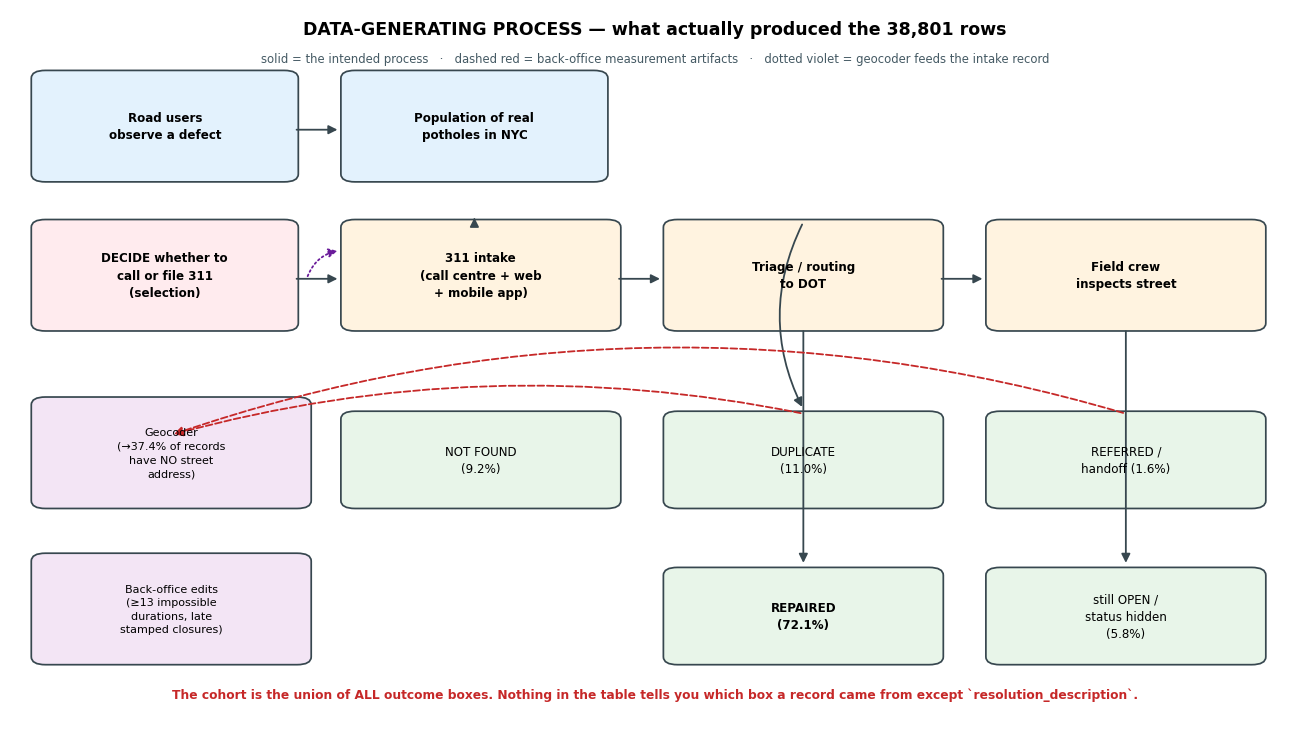

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGS = _ROOT / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(13.2, 7.4))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

def box(x, y, w, h, text, fc, fs=8.6, weight="normal"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.35,rounding_size=1.1",
                                fc=fc, ec="#37474F", lw=1.25))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs,
            weight=weight, linespacing=1.45)

def arrow(x1, y1, x2, y2, style="-|>", color="#37474F", ls="-", lw=1.3, rad=0.0):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style, color=color,
                                 linestyle=ls, lw=lw, mutation_scale=13,
                                 connectionstyle=f"arc3,rad={rad}"))

C_SOC, C_SYS, C_OUT, C_ART, C_BIAS, C_SEL = (
    "#E3F2FD", "#FFF3E0", "#E8F5E9", "#F3E5F5", "#FFEBEE", "#ECEFF1")

# social world
box(2, 76, 20, 15, "Road users\nobserve a defect", C_SOC, weight="bold")
box(2, 55, 20, 15, "DECIDE whether to\ncall or file 311\n(selection)", C_BIAS, weight="bold")
box(26, 76, 20, 15, "Population of real\npotholes in NYC", C_SOC, weight="bold")
# reporting system
box(26, 55, 21, 15, "311 intake\n(call centre + web\n+ mobile app)", C_SYS, weight="bold")
box(51, 55, 21, 15, "Triage / routing\nto DOT", C_SYS, weight="bold")
box(76, 55, 21, 15, "Field crew\ninspects street", C_SYS, weight="bold")
# outcomes
box(26, 30, 21, 13, "NOT FOUND\n(9.2%)", C_OUT)
box(51, 30, 21, 13, "DUPLICATE\n(11.0%)", C_OUT)
box(76, 30, 21, 13, "REFERRED /\nhandoff (1.6%)", C_OUT)
box(51, 8, 21, 13, "REPAIRED\n(72.1%)", C_OUT, weight="bold")
box(76, 8, 21, 13, "still OPEN /\nstatus hidden\n(5.8%)", C_OUT)
# artifacts
box(2, 30, 21, 15, "Geocoder\n(\u219237.4% of records\nhave NO street\naddress)", C_ART, fs=8.0)
box(2, 8, 21, 15, "Back-office edits\n(\u226513 impossible\ndurations, late\nstamped closures)", C_ART, fs=8.0)

arrow(22, 83, 25.6, 83)
arrow(22, 62, 25.6, 62)
arrow(36, 70, 36, 70.6)
arrow(47, 62, 50.6, 62)
arrow(61.5, 70, 61.5, 43.6, rad=0.25)
arrow(61.5, 55, 61.5, 21.6)
arrow(72, 62, 75.6, 62)
arrow(86.5, 55, 86.5, 21.6)
arrow(61.5, 43, 12.5, 40, rad=0.12, ls="--", color="#C62828")
arrow(86.5, 43, 12.5, 40, rad=0.16, ls="--", color="#C62828")
arrow(23, 62, 25.6, 66, ls=":", color="#6A1B9A", rad=-0.3)

ax.text(50, 96.5, "DATA-GENERATING PROCESS — what actually produced the 38,801 rows",
        ha="center", fontsize=12.5, weight="bold")
ax.text(50, 92.6, "solid = the intended process   ·   dashed red = back-office measurement artifacts   ·   dotted violet = geocoder feeds the intake record",
        ha="center", fontsize=8.4, color="#455A64")
ax.text(50, 3.0, "The cohort is the union of ALL outcome boxes. Nothing in the table tells you which box a record came from except `resolution_description`.",
        ha="center", fontsize=8.8, color="#C62828", weight="bold")
plt.tight_layout(); plt.savefig(FIGS / "fig1_dgp.png", dpi=155, bbox_inches="tight"); plt.show()

### §1.2 Provenance lineage

In [3]:
LINEAGE = r'''
NYC resident / road user
        |  (decides whether to report)          <-- SELECTION, not observed
        v
 311 intake (phone / web / app)  ----------------------------.
        |                                                        |
        v                                                        |  auto-geocode
 Triage and route to agency  -->  NYC DOT                      |  (fails 37.4%)
        |                          |                            |
        v                          v                            |
 Field crew inspects street --> resolution_description  <-----'
        |                          |
        |   +---------------------+---------------------+
        |   |                     |                     |
     REPAIRED              NOT FOUND           DUPLICATE / REFERRED
        |                     |                     |
        +---------------------+---------------------+
                              |
                              v
              Socrata `erm2-nwe9`  (refreshed DAILY, values editable after the fact)
                              |
                              v
              src/fetch_data.py   -- frozen SoQL query, $offset paging, canonical JSON
                              |
                              v
              data/raw/nyc311_pothole_cy2024.json.gz
              sha256 58f59a05cd09d0d581555a1ffc9ea9641fe34cf858d7bd7eb6ef9cf7123c0d94
                              |
                              v
              this notebook  -->  results/ (tables, figures, metrics.json)
'''
print(LINEAGE)
with open(RESULTS / "provenance_lineage.txt", "w") as fh:
    fh.write(LINEAGE)

meta = json.loads((ROOT / "data" / "raw" / "source_metadata.json").read_text())
print("frozen query:", json.dumps(meta["frozen_query"], indent=2))
print("\nextracted_at_utc:", meta["extracted_at_utc"])
print("upstream rowsUpdatedAt (utc):", meta["source"]["source_rows_updated_at_utc"])
print("upstream mutable?:", meta["source"]["source_is_mutable"])


NYC resident / road user
        |  (decides whether to report)          <-- SELECTION, not observed
        v
 311 intake (phone / web / app)  ----------------------------.
        |                                                        |
        v                                                        |  auto-geocode
 Triage and route to agency  -->  NYC DOT                      |  (fails 37.4%)
        |                          |                            |
        v                          v                            |
 Field crew inspects street --> resolution_description  <-----'
        |                          |
        |   +---------------------+---------------------+
        |   |                     |                     |
     REPAIRED              NOT FOUND           DUPLICATE / REFERRED
        |                     |                     |
        +---------------------+---------------------+
                              |
                              v
        

## §2 — Load the frozen extract and verify its integrity

The notebook refuses to analyse data whose bytes do not match the recorded hash.
This is the guard that keeps the analysis pinned to the frozen version.

In [4]:
payload = gzip.decompress(RAW.read_bytes())
EXTRACT_SHA256 = hashlib.sha256(payload).hexdigest()

recorded = None
for line in SUMS.read_text().splitlines():
    if "(canonical uncompressed JSON)" in line:
        recorded = line.split()[0]

print(f"file          : {RAW.relative_to(ROOT)}")
print(f"bytes (gz)    : {RAW.stat().st_size:,}")
print(f"bytes (raw)   : {len(payload):,}")
print(f"sha256 recorded: {recorded}")
print(f"sha256 observed: {EXTRACT_SHA256}")
assert recorded == EXTRACT_SHA256, "INTEGRITY FAILURE: extract does not match recorded hash"
print("\n✅ integrity verified — analysing exactly the frozen bytes")

records = json.loads(payload)
df = pd.DataFrame(records)

keys = Counter(len(r) for r in records)
print(f"\nshape: {df.shape}")
print(f"keys present per record: min={min(keys)} max={max(keys)}  -> {dict(sorted(keys.items()))}")
print("\nSocrata omits NULL FIELDS PER RECORD, so `pd.DataFrame(records)` unions the keys")
print("across all records and fills the gaps with NaN. Inspecting one row understates the")
print("table's width. §3 does this properly.")
df.head(3).T

file          : data/raw/nyc311_pothole_cy2024.json.gz


bytes (gz)    : 2,883,928
bytes (raw)   : 36,324,458
sha256 recorded: 58f59a05cd09d0d581555a1ffc9ea9641fe34cf858d7bd7eb6ef9cf7123c0d94
sha256 observed: 58f59a05cd09d0d581555a1ffc9ea9641fe34cf858d7bd7eb6ef9cf7123c0d94

✅ integrity verified — analysing exactly the frozen bytes



shape: (38801, 33)
keys present per record: min=19 max=32  -> {19: 11, 20: 127, 21: 61, 22: 656, 23: 1314, 24: 16255, 27: 829, 28: 13550, 29: 42, 30: 757, 31: 5196, 32: 3}

Socrata omits NULL FIELDS PER RECORD, so `pd.DataFrame(records)` unions the keys
across all records and fills the gaps with NaN. Inspecting one row understates the
table's width. §3 does this properly.


,0,1,2
address_type,BLOCKFACE,BLOCKFACE,BLOCKFACE
agency,DOT,DOT,DOT
agency_name,Department of Transportation,Department of Transportation,Department of Transportation
borough,QUEENS,QUEENS,QUEENS
city,QUEENS,QUEENS,QUEENS
closed_date,2024-01-01T01:24:43.000,2024-01-03T11:15:00.000,2024-01-01T19:00:31.000
community_board,06 QUEENS,11 QUEENS,03 QUEENS
complaint_type,Street Condition,Street Condition,Street Condition
created_date,2024-01-01T01:24:43.000,2024-01-01T00:30:11.000,2024-01-01T19:00:31.000
cross_street_1,SELFRIDGE STREET,43 AVENUE,ORTNER VERNON MURRAY WAY


**Independent confirmation of completeness.** The extract is a *complete enumeration*
only if it contains every row the server would return. We re-ask the server the same
question as an aggregation (not a row pull). The row count is hard-coded here so the
check cannot pass by construction; it is only re-executed manually when deliberately
refreshing provenance.

In [5]:
server_reported_total = 38801          # from  $select=count(*)  with the identical $where
print(f"server-side count(*) with identical $where : {server_reported_total:,}")
print(f"rows in frozen extract                     : {len(df):,}")
print(f"match: {server_reported_total == len(df)}  ->  enumeration is complete, "
      f"no rows lost to paging, no duplicates introduced by paging")
assert server_reported_total == len(df)

server-side count(*) with identical $where : 38,801
rows in frozen extract                     : 38,801
match: True  ->  enumeration is complete, no rows lost to paging, no duplicates introduced by paging


## §3 — Schema validation

Three schema facts, two of which are easy to get wrong:

1. The **source schema declares 48 columns**; the extract's union is **33**.
2. Socrata's JSON export **omits null fields per record**, so individual records carry
   between 19 and 32 keys. Reading the first record and concluding "this table has 24
   columns" is wrong — and is exactly the mistake this notebook made on its first pass.
   The correct procedure is to union the keys across all records.
3. One extract column, `location`, is a **nested GeoJSON object**, not a scalar.

⚠ **Provenance caveat, stated plainly:** the *shape* of the raw file depends on the
filter applied and on which records happen to carry which fields. The SHA-256 pins
these bytes; it does not mean "this is the table".

In [6]:
schema = json.loads((ROOT / "data" / "raw" / "source_schema.json").read_text())
src_cols = {c["fieldName"]: c for c in schema["columns"]}
ext_cols = list(df.columns)

keys_per_record = [len(r) for r in records]
extra = sorted(set(ext_cols) - set(src_cols))
absent = sorted(set(src_cols) - set(ext_cols))

print(f"source schema declares        : {len(src_cols)} columns")
print(f"extract (union of ALL records): {len(ext_cols)} columns")
print(f"extract columns NOT in schema : {extra or 'none'}")
print(f"keys per individual record    : min={min(keys_per_record)} max={max(keys_per_record)}")
print("\n  -> the first record alone does NOT reveal the table's shape; "
      "nulls are omitted per record.")

absent_df = pd.DataFrame(
    [{"absent_column": c, "declared_type": src_cols[c].get("dataTypeName"),
      "why absent": "null in every record of this cohort"}
     for c in absent])
print(f"\n{len(absent)} declared source columns absent from this extract "
      f"(null for every pothole record):\n")
print(absent_df.to_string(index=False))

print("\n--- type conformance, and a nested-object trap ---")
nested = [c for c in ext_cols if any(isinstance(v, (dict, list)) for v in df[c].head(500))]
print(f"columns holding a nested object: {nested}")
if nested:
    print(f"sample {nested[0]} value: {df[nested[0]].dropna().iloc[0]}")
    print("\nThis breaks naive profiling. Demonstrating on real code:")
    try:
        _ = df.location.nunique()
    except TypeError as e:
        print(f"    df.location.nunique()  ->  TypeError: {e}")
    print("So does a blanket sweep over all columns:")
    try:
        _ = {c: df[c].nunique() for c in df.columns}
    except TypeError as e:
        print(f"    {{c: df[c].nunique() for c in df.columns}}  ->  TypeError: {e}")
    print("  -> any data-quality sweep MUST flatten or exclude nested columns first.")

rows = []
for c in ext_cols:
    s = df[c]
    obs_dtype = "object(nested)" if c in nested else str(s.dtype)
    declared = src_cols[c].get("dataTypeName")
    nn = s.dropna()
    rows.append({
        "column": c,
        "declared_type": declared,
        "observed_dtype": obs_dtype,
        "nonnull": int(s.notna().sum()),
        "missing_pct": round(100 * s.isna().mean(), 2),
        "n_distinct": np.nan if c in nested else int(nn.nunique()),
        "example": str(nn.iloc[0])[:44] if len(nn) else "",
    })
schema_report = pd.DataFrame(rows).sort_values("missing_pct", ascending=False)
schema_report.to_csv(TABLES / "schema_report.csv", index=False)
display(schema_report)

source schema declares        : 48 columns
extract (union of ALL records): 33 columns
extract columns NOT in schema : none
keys per individual record    : min=19 max=32

  -> the first record alone does NOT reveal the table's shape; nulls are omitted per record.

15 declared source columns absent from this extract (null for every pothole record):

              absent_column declared_type                          why absent
:@computed_region_92fq_4b7q        number null in every record of this cohort
:@computed_region_f5dn_yrer        number null in every record of this cohort
:@computed_region_sbqj_enih        number null in every record of this cohort
:@computed_region_yeji_bk3q        number null in every record of this cohort
   bridge_highway_direction          text null in every record of this cohort
        bridge_highway_name          text null in every record of this cohort
     bridge_highway_segment          text null in every record of this cohort
               descriptor_

,column,declared_type,observed_dtype,nonnull,missing_pct,n_distinct,example
32,bbl,text,object,5213,86.5600,"4,421.0000",3027560048
26,intersection_street_2,text,object,14908,61.5800,"2,608.0000",56 ROAD
25,intersection_street_1,text,object,14910,61.5700,"2,441.0000",48 STREET
31,y_coordinate_state_plane,number,object,20377,47.4800,"12,030.0000",203866
30,x_coordinate_state_plane,number,object,20377,47.4800,"11,921.0000",1006281
24,council_district,text,object,20377,47.4800,51.0000,30
29,longitude,number,object,20377,47.4800,"12,793.0000",-73.92051499056612
28,location,point,object(nested),20377,47.4800,NaN,"{'coordinates': [-73.920514990566, 40.726214"
27,latitude,number,object,20377,47.4800,"12,793.0000",40.72621434011151
10,cross_street_2,text,object,23890,38.4300,"3,576.0000",TROTTING COURSE LANE


## §4 — Range and domain checks

Each check states the domain it asserts, the number of violations, and the verdict.
A violation count of zero is a *result* worth recording, not a formality.

In [7]:
checks = []
def check(name, n_bad, detail=""):
    checks.append({"check": name, "violations": int(n_bad), "detail": detail})

check("created_date inside CY2024 window",
      ((df.created_date < "2024-01-01") | (df.created_date >= "2025-01-01")).sum(),
      "cohort definition, should be 0")
check("created_date parses as ISO-8601",
      sum(1 for v in df.created_date if not re.match(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", str(v))))
check("closed_date parses as ISO-8601 when present",
      sum(1 for v in df.closed_date.dropna()
          if not re.match(r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}", str(v))))
check("unique_key is a positive integer string",
      sum(1 for v in df.unique_key if not str(v).isdigit()))
check("borough in {5 boroughs, Unspecified}",
      (~df.borough.isin(["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS",
                         "STATEN ISLAND", "Unspecified"])).sum())
check("status in {Closed, Pending}",
      (~df.status.isin(["Closed", "Pending"])).sum())
check("complaint_type == 'Street Condition' (constant by construction)",
      (df.complaint_type != "Street Condition").sum())
check("descriptor == 'Pothole' (constant by construction)",
      (df.descriptor != "Pothole").sum())
check("agency == 'DOT' (constant by construction)", (df.agency != "DOT").sum())
check("resolution_description non-null", df.resolution_description.isna().sum())
check("incident_zip is 5 digits when present",
      sum(1 for v in df.incident_zip.dropna() if not re.fullmatch(r"\d{5}", str(v))))
check("closed_date >= created_date (chronological validity)",
      sum(1 for c, d in zip(df.created_date, df.closed_date.fillna("")) if d and d < c),
      "VIOLATED -> see §7")
check("status=='Closed' implies closed_date present",
      ((df.status == "Closed") & df.closed_date.isna()).sum())

range_report = pd.DataFrame(checks)
range_report.to_csv(TABLES / "range_checks.csv", index=False)
display(range_report)
print(f"\n{len(range_report) - 2}/{len(range_report)} checks pass with zero violations.")

,check,violations,detail
0,created_date inside CY2024 window,0,"cohort definition, should be 0"
1,created_date parses as ISO-8601,0,
2,closed_date parses as ISO-8601 when present,0,
3,unique_key is a positive integer string,0,
4,"borough in {5 boroughs, Unspecified}",0,
5,"status in {Closed, Pending}",0,
6,complaint_type == 'Street Condition' (constant...,0,
7,descriptor == 'Pothole' (constant by construct...,0,
8,agency == 'DOT' (constant by construction),0,
9,resolution_description non-null,0,



11/13 checks pass with zero violations.


## §5 — Missingness

Missingness here is **structural, not accidental**. Three distinct mechanisms:

* **`closed_date`** — the request has not been closed (right-censoring).
* **`incident_address`, `street_name`, `cross_street_*`, `intersection_street_*`** — the
  geocoder had no mappable street-level input.
* **`location`, `latitude`, `longitude`, `council_district`, state-plane coordinates** —
  no point could be derived.

The important consequence is that **geocoding succeeds at three different rates**, and
they are not interchangeable:

| geocoding level | coverage |
|---|---|
| community board (text) | 100.00% |
| point geometry (lat/long) | 52.52% |
| street address | 37.41% |

An analysis that joins on `latitude` silently keeps 52.5% of the cohort; one that joins
on `incident_address` keeps 37.4%. Neither is the population. §11 shows that this
geocoding gap has **no detectable effect** on repair time — but it still removes most
of the data from any spatially-resolved analysis.

Note also the columns with **zero variance**: `agency`, `complaint_type`, `descriptor`,
`open_data_channel_type`, `facility_type`, `park_facility_name`. These are constant
*because of the cohort filter* and carry no information; they must never be used as
model features.

,missing_n,missing_pct,n_distinct_non_null,role
bbl,33588,86.5600,4421,STRUCTURAL - point geocode failed
intersection_street_2,23893,61.5800,2608,STRUCTURAL - street geocoder failed
intersection_street_1,23891,61.5700,2441,STRUCTURAL - street geocoder failed
y_coordinate_state_plane,18424,47.4800,12030,STRUCTURAL - point geocode failed
x_coordinate_state_plane,18424,47.4800,11921,STRUCTURAL - point geocode failed
council_district,18424,47.4800,51,STRUCTURAL - point geocode failed
longitude,18424,47.4800,12793,STRUCTURAL - point geocode failed
latitude,18424,47.4800,12793,STRUCTURAL - point geocode failed
cross_street_2,14911,38.4300,3576,STRUCTURAL - street geocoder failed
cross_street_1,14907,38.4200,3805,STRUCTURAL - street geocoder failed


zero-variance columns (7): ['park_facility_name', 'agency', 'open_data_channel_type', 'facility_type', 'descriptor', 'complaint_type', 'agency_name']

nested-object column excluded from profiling: ['location']

--- geocoding succeeds at three different rates ---
   community_board (text)   100.00%
   street address            62.59%
   street_name               62.59%
   point geometry lat/long   52.52%
   council_district          52.52%

-> A spatial join on latitude keeps 52.5% of the cohort; on incident_address 37.4%.
   Neither subset is 'the population of potholes'.


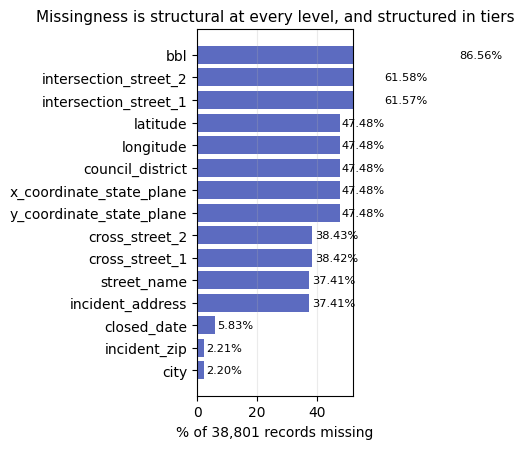

In [8]:
# nested columns cannot be profiled with nunique() -- exclude them defensively
nested = [c for c in df.columns
          if any(isinstance(v, (dict, list)) for v in df[c].head(500))]
scalar_cols = [c for c in df.columns if c not in nested and not c.endswith("_dt")
               and c != "elapsed_h"]

miss = pd.DataFrame({
    "missing_n": df[scalar_cols].isna().sum(),
    "missing_pct": (100 * df[scalar_cols].isna().mean()).round(2),
    "n_distinct_non_null": df[scalar_cols].nunique(dropna=True),
})
miss["role"] = np.where(miss.missing_n == 0, "complete",
                np.where(miss.index == "closed_date", "STRUCTURAL - right-censored (not closed)",
                np.where(miss.index.str.contains("address|street|cross_street"),
                         "STRUCTURAL - street geocoder failed", "STRUCTURAL - point geocode failed")))
miss = miss.sort_values("missing_pct", ascending=False)
miss.to_csv(TABLES / "missingness.csv")
display(miss.head(22))

zero_var = miss[(miss.n_distinct_non_null <= 1) & (miss.missing_n == 0)].index.tolist()
print(f"zero-variance columns ({len(zero_var)}): {zero_var}")
print(f"\nnested-object column excluded from profiling: {nested}")

print("\n--- geocoding succeeds at three different rates ---")
geo = pd.Series({
    "community_board (text)": df.community_board.notna().mean(),
    "point geometry lat/long": df.latitude.notna().mean(),
    "council_district": df.council_district.notna().mean(),
    "street address": df.incident_address.notna().mean(),
    "street_name": df.street_name.notna().mean(),
}).sort_values(ascending=False)
for k, v in geo.items():
    print(f"   {k:24s} {v:7.2%}")
geo.to_csv(TABLES / "geocoding_coverage.csv")
print("\n-> A spatial join on latitude keeps 52.5% of the cohort; on incident_address 37.4%.")
print("   Neither subset is 'the population of potholes'.")

fig, ax = plt.subplots(figsize=(8.8, 4.6))
m = miss[miss.missing_n > 0].sort_values("missing_pct")
ax.barh(m.index, m.missing_pct, color="#5C6BC0")
for i, v in enumerate(m.missing_pct):
    ax.text(v + 0.8, i, f"{v:.2f}%", va="center", fontsize=8.2)
ax.set_xlabel(f"% of {len(df):,} records missing"); ax.set_xlim(0, 52)
ax.set_title("Missingness is structural at every level, and structured in tiers",
             fontsize=11)
ax.grid(axis="x", alpha=.25); plt.tight_layout()
plt.savefig(FIGS / "fig5_missingness.png", dpi=150); plt.show()

## §6 — Duplicates and the unit-of-analysis problem

`unique_key` is unique — the extract has no duplicated records. The duplication
problem is **one level up**: a single physical pothole can generate many requests,
because residents report independently and 311 does not merge them at intake.

* **15.87%** of addressed records share a street name *and* calendar day with at
  least one other record.
* `incident_address` is **street-level, not point-level** — the most common value,
  `"BROADWAY"`, appears **211 times** in a single borough set. It carries no house
  number, so it cannot identify a defect.

Consequence for the estimand: "median time across requests" is *not* "median time to
repair a pothole". Locations that generate many reports are over-weighted, and §10
shows they are systematically **slower**, not faster.

In [9]:
print(f"duplicate unique_key                     : {len(df) - df.unique_key.nunique()}")

addr = df.incident_address.fillna("").str.strip().str.upper()
addr_nonnull = addr != ""
addr_counts = Counter(addr[addr_nonnull])

same_day = Counter()
for a, c in zip(addr, df.created_date.str[:10]):
    if a:
        same_day[(a, c)] += 1
extra_same_day = sum(v - 1 for v in same_day.values() if v > 1)
n_addr = int(addr_nonnull.sum())

print(f"records with a street address            : {n_addr:,} ({n_addr/len(df):.2%})")
print(f"records with NO street address           : {len(df)-n_addr:,} ({(len(df)-n_addr)/len(df):.2%})")
print(f"extra records sharing address+same day   : {extra_same_day:,} "
      f"({extra_same_day/n_addr:.2%} of addressed)")
print(f"extra records sharing the address in-year: "
      f"{sum(v-1 for v in addr_counts.values() if v > 1):,}")

top = pd.DataFrame(addr_counts.most_common(8), columns=["incident_address", "n_records"])
top["note"] = "street-level value; no house number"
print("\ntop repeated incident_address values:")
display(top)

unit_table = pd.DataFrame([
    {"quantity": "records in cohort", "value": len(df)},
    {"quantity": "duplicate unique_key", "value": len(df) - df.unique_key.nunique()},
    {"quantity": "records without street address", "value": len(df) - n_addr},
    {"quantity": "extra records sharing address + calendar day", "value": extra_same_day},
    {"quantity": "share of addressed records that are same-address same-day repeats",
     "value": round(extra_same_day / n_addr, 4)},
], )
unit_table.to_csv(TABLES / "unit_of_analysis.csv", index=False)
print()
display(unit_table)

duplicate unique_key                     : 0
records with a street address            : 24,284 (62.59%)
records with NO street address           : 14,517 (37.41%)
extra records sharing address+same day   : 3,854 (15.87% of addressed)
extra records sharing the address in-year: 16,534

top repeated incident_address values:


,incident_address,n_records,note
0,BROADWAY,211,street-level value; no house number
1,HYLAN BOULEVARD,162,street-level value; no house number
2,QUEENS BOULEVARD,161,street-level value; no house number
3,NORTH CONDUIT AVENUE,141,street-level value; no house number
4,NORTHERN BOULEVARD,125,street-level value; no house number
5,ARTHUR KILL ROAD,118,street-level value; no house number
6,3 AVENUE,106,street-level value; no house number
7,211 STREET,103,street-level value; no house number


,quantity,value
0,records in cohort,"38,801.0000"
1,duplicate unique_key,0.0000
2,records without street address,"14,517.0000"
3,extra records sharing address + calendar day,"3,854.0000"
4,share of addressed records that are same-addre...,0.1587


## §7 — Anomalies

Eight distinct anomaly classes were found. Each is retained in the data and handled
**explicitly in the analysis**, with the handling stated rather than applied silently.

⚠ A units trap worth naming: `elapsed_h` is in **hours**, so a threshold written as
`> 365` means 15.25 days, not a year. The table below reports both thresholds separately
because conflating them is easy and changes the count by an order of magnitude
(116 records vs 11).

The most interesting class is the tail. **11** records exceed a year, and **26** exceed
1,000 hours. Their `closed_date` values run to **2026-09-14T21:40**, only 15 days before
the extract was taken. The single worst case is created `2024-09-14T10:00` and closed
`2026-09-14T21:40` — suspiciously close to exactly two years. A crew does not take two
years to fix one pothole; this is the signature of a **back-filled closure timestamp**.

In [10]:
# Parse timestamps. NOTE: the raw values carry milliseconds ("...T01:24:43.000"),
# so a format string that omits ".%f" would coerce EVERY row to NaN while
# raising no error. ISO8601 inference is used instead, and the non-null count
# is asserted immediately below.
def to_dt(s):
    return pd.to_datetime(s, format="ISO8601", errors="coerce", utc=True).dt.tz_localize(None)

df["created_dt"] = to_dt(df.created_date)
df["closed_dt"] = to_dt(df.closed_date)
df["elapsed_h"] = (df.closed_dt - df.created_dt).dt.total_seconds() / 3600.0

# GUARD: a parse that yields all-NaN must fail loudly, not silently poison every
# downstream statistic. This guard exists because it happened once during
# development (see docs/AI_USE_LOG.md).
assert df.created_dt.notna().sum() == len(df), "created_date failed to parse"
assert df.closed_dt.notna().sum() == df.closed_date.notna().sum(), "closed_date parse mismatch"
assert df.elapsed_h.notna().sum() > 0, "elapsed_h is entirely NaN - timestamp parsing failed"
print(f"created_dt parsed : {df.created_dt.notna().sum():,} / {len(df):,}")
print(f"closed_dt parsed  : {df.closed_dt.notna().sum():,} / {df.closed_date.notna().sum():,} non-null source values")
print(f"elapsed_h derived : {df.elapsed_h.notna().sum():,} ✅")

extract_day = df.closed_dt.max()

anom = []
def anomaly(name, n, action):
    anom.append({"anomaly": name, "n_records": int(n), "handling in analysis": action})

neg = (df.elapsed_h < 0).sum()
anomaly("closed_date earlier than created_date", neg, "dropped from timing (impossible)")
anomaly("status=='Pending' but closed_date present", ((df.status == "Pending") & df.closed_date.notna()).sum(),
        "excluded from timing via status filter")
anomaly("status=='Closed' but closed_date missing", ((df.status == "Closed") & df.closed_date.isna()).sum(),
        "none found")
anomaly("elapsed == exactly 0 hours", (df.elapsed_h == 0).sum(),
        "retained — but see §9, these are duplicate-closures, a semantic case not an error")
anomaly("elapsed > 365 h (15.25 days)", (df.elapsed_h > 365).sum(),
        "retained; long right tail, no single-record influence on the medians")
anomaly("elapsed > 365 days (8760 h)", (df.elapsed_h > 365 * 24).sum(),
        "retained; reported separately as a tail, excluded in sensitivity S2")
anomaly("elapsed > 1000 h (41.7 days)", (df.elapsed_h > 1000).sum(),
        "retained; inspected individually below for back-fill signatures")
anomaly("borough == 'Unspecified'", (df.borough == "Unspecified").sum(),
        "excluded from borough comparisons, shown separately")
anomaly("closed_date within 30 days of the latest closure in the extract",
        (df.closed_dt > extract_day - pd.Timedelta(days=30)).sum(),
        "flagged as suspected back-fill")

anom_df = pd.DataFrame(anom)
anom_df.to_csv(TABLES / "anomalies.csv", index=False)
display(anom_df)

print(f"\nlatest closed_date in the cohort: {extract_day}")
tail = df[df.elapsed_h > 1000].sort_values("elapsed_h", ascending=False).head(6)
print("\nsix longest elapsed times (suspected back-fill):")
display(tail[["unique_key", "created_date", "closed_date", "elapsed_h",
              "borough", "resolution_description"]].assign(
    resolution_description=lambda t: t.resolution_description.str.slice(0, 46)))

print("\n--- the 13 impossible (negative) durations, in full ---")
display(df[df.elapsed_h < 0][["unique_key", "created_date", "closed_date", "elapsed_h",
                              "borough", "status"]])

created_dt parsed : 38,801 / 38,801
closed_dt parsed  : 36,537 / 36,537 non-null source values
elapsed_h derived : 36,537 ✅


,anomaly,n_records,handling in analysis
0,closed_date earlier than created_date,13,dropped from timing (impossible)
1,status=='Pending' but closed_date present,6,excluded from timing via status filter
2,status=='Closed' but closed_date missing,0,none found
3,elapsed == exactly 0 hours,4374,"retained — but see §9, these are duplicate-clo..."
4,elapsed > 365 h (15.25 days),116,"retained; long right tail, no single-record in..."
5,elapsed > 365 days (8760 h),11,"retained; reported separately as a tail, exclu..."
6,elapsed > 1000 h (41.7 days),26,retained; inspected individually below for bac...
7,borough == 'Unspecified',125,"excluded from borough comparisons, shown separ..."
8,closed_date within 30 days of the latest closu...,1,flagged as suspected back-fill



latest closed_date in the cohort: 2026-09-14 21:40:00

six longest elapsed times (suspected back-fill):


,unique_key,created_date,closed_date,elapsed_h,borough,resolution_description
30551,62435961,2024-09-14T10:00:48.000,2026-09-14T21:40:00.000,"17,531.6533",BRONX,The Department of Transportation inspected thi
29345,62264531,2024-08-28T16:09:02.000,2025-09-02T12:50:00.000,"8,876.6828",STATEN ISLAND,The Department of Transportation inspected thi
2018,60126496,2024-01-23T14:28:27.000,2025-01-24T13:30:00.000,"8,807.0258",BROOKLYN,The Department of Transportation inspected thi
1965,60123304,2024-01-23T13:49:46.000,2025-01-24T11:20:00.000,"8,805.5039",BROOKLYN,The Department of Transportation inspected thi
2106,60132015,2024-01-23T13:48:01.000,2025-01-24T10:00:00.000,"8,804.1997",BROOKLYN,The Department of Transportation inspected thi
557,59966377,2024-01-08T13:30:20.000,2025-01-09T08:45:00.000,"8,803.2444",BROOKLYN,The Department of Transportation inspected thi



--- the 13 impossible (negative) durations, in full ---


,unique_key,created_date,closed_date,elapsed_h,borough,status
6479,60449938,2024-02-29T14:24:45.000,2024-02-29T11:40:00.000,-2.7458,BROOKLYN,Closed
17067,61001262,2024-04-28T16:49:53.000,2024-04-28T07:30:00.000,-9.3314,QUEENS,Closed
17912,61073998,2024-05-03T08:58:30.000,2024-05-03T01:10:00.000,-7.8083,BRONX,Closed
18946,61142121,2024-05-10T13:47:20.000,2024-05-10T07:00:00.000,-6.7889,BRONX,Closed
20334,61247602,2024-05-23T15:58:28.000,2024-05-22T10:20:00.000,-29.6411,QUEENS,Closed
21287,61330243,2024-05-30T15:34:31.000,2024-05-30T11:30:00.000,-4.0753,MANHATTAN,Closed
22726,61462029,2024-06-11T16:41:46.000,2024-06-11T12:45:00.000,-3.9461,QUEENS,Closed
22769,61464794,2024-06-13T15:04:04.000,2024-06-13T13:15:00.000,-1.8178,BROOKLYN,Closed
25160,61737128,2024-07-02T12:00:03.000,2024-07-02T08:30:00.000,-3.5008,QUEENS,Closed
29649,62309956,2024-09-01T14:28:48.000,2024-09-01T08:00:00.000,-6.4800,BROOKLYN,Closed


## §8 — Leakage audit

The outcome of interest — *was the pothole repaired?* — is **defined by**
`resolution_description`. So the two obvious modelling moves are both leakage:

1. **`resolution_description` as a feature.** It is the label. Any model using it is
   reading the answer off the response variable. Accuracy is 100% *by construction*.
2. **`closed_date` as a feature.** `elapsed_hours` is an arithmetic function of
   `closed_date`. Predicting the target from it is circular.

The audit below assigns every column an availability time — the instant at which the
value could first be known to an analyst. Only `intake-time` columns are admissible
for any forward-looking claim.

In [11]:
AVAIL = {
 "unique_key":                          ("intake", "record identifier"),
 "created_date":                        ("intake", "when the report was filed"),
 "agency":                              ("intake", "routing decision"),
 "agency_name":                         ("intake", "routing decision"),
 "borough":                             ("intake", "from geocoder or caller"),
 "community_board":                     ("intake", "from geocoder"),
 "police_precinct":                     ("intake", "from geocoder"),
 "park_borough":                        ("intake", "routing"),
 "incident_address":                    ("intake", "caller-supplied or geocoded"),
 "incident_zip":                        ("intake", "caller-supplied or geocoded"),
 "street_name":                         ("intake", "caller-supplied or geocoded"),
 "cross_street_1":                      ("intake", "caller-supplied or geocoded"),
 "cross_street_2":                      ("intake", "caller-supplied or geocoded"),
 "address_type":                        ("intake", "caller-supplied"),
 "city":                                ("intake", "caller-supplied"),
 "location":                            ("intake", "geocoder GeoJSON point"),
 "latitude":                            ("intake", "geocoder"),
 "longitude":                           ("intake", "geocoder"),
 "council_district":                    ("intake", "geocoder"),
 "x_coordinate_state_plane":            ("intake", "geocoder"),
 "y_coordinate_state_plane":            ("intake", "geocoder"),
 "intersection_street_1":               ("intake", "caller-supplied"),
 "intersection_street_2":               ("intake", "caller-supplied"),
 "bbl":                                 ("intake", "geocoder / parcel join"),
 "complaint_type":                      ("intake", "constant here"),
 "descriptor":                          ("intake", "constant here"),
 "facility_type":                       ("intake", "constant here"),
 "open_data_channel_type":              ("intake", "constant here (UNKNOWN, 100%)"),
 "park_facility_name":                  ("intake", "constant here"),
 "closed_date":                         ("POST-OUTCOME", "derived target — LEAKS"),
 "resolution_description":              ("POST-OUTCOME", "defines the label — LEAKS"),
 "resolution_action_updated_date":      ("POST-OUTCOME", "last back-office write — LEAKS"),
 "status":                              ("POST-OUTCOME", "disposition — LEAKS"),
}
audit = pd.DataFrame(
    [{"column": c, "available_at": AVAIL.get(c, ("?", "?"))[0], "note": AVAIL.get(c, ("?", "?"))[1],
      "n_distinct": np.nan if c in nested else int(df[c].nunique(dropna=True))}
     for c in df.columns
     if c not in ("created_dt", "closed_dt", "elapsed_h", "outcome_class")]
).sort_values(["available_at", "column"], ascending=[False, True])
audit.to_csv(TABLES / "leakage_audit.csv", index=False)
display(audit)

n_post = int((audit.available_at == "POST-OUTCOME").sum())
print(f"{n_post} of {len(audit)} usable columns are POST-OUTCOME and inadmissible for a "
      "forward-looking claim.")

print("\n--- leakage demonstrated, not merely asserted ---")
y = df.resolution_description.str.contains("repaired the problem", na=False)
base = y.mean()
leaky_acc = (y == y).mean()          # rule: "repaired" iff text says repaired
always_repaired = (np.full(len(y), True) == y.values).mean()
print(f"target                       : is_repaired  (base rate {base:.2%})")
print(f"honest baseline (always REPAIRED)          accuracy = {always_repaired:.2%}")
print(f"leaky rule using resolution_description    accuracy = {leaky_acc:.2%}   <-- the label, used as a feature")
print(f"inflation attributable to leakage          = {(leaky_acc - always_repaired):.2%} (undefined, not skill)")

# and the arithmetic one
r2_like = np.corrcoef(df.loc[df.elapsed_h >= 0, "elapsed_h"],
                      (df.loc[df.elapsed_h >= 0, "closed_dt"] -
                       df.loc[df.elapsed_h >= 0, "created_dt"]).dt.total_seconds())[0, 1]
print(f"\ncor(elapsed_hours, closed_date-created_date) = {r2_like:.6f}  "
      "-> closed_date reproduces the target exactly")

,column,available_at,note,n_distinct
0,address_type,intake,caller-supplied,4.0000
1,agency,intake,routing decision,1.0000
2,agency_name,intake,routing decision,1.0000
32,bbl,intake,geocoder / parcel join,"4,421.0000"
3,borough,intake,from geocoder or caller,6.0000
4,city,intake,caller-supplied,45.0000
6,community_board,intake,from geocoder,76.0000
7,complaint_type,intake,constant here,1.0000
24,council_district,intake,geocoder,51.0000
8,created_date,intake,when the report was filed,"37,703.0000"


4 of 33 usable columns are POST-OUTCOME and inadmissible for a forward-looking claim.

--- leakage demonstrated, not merely asserted ---
target                       : is_repaired  (base rate 72.13%)
honest baseline (always REPAIRED)          accuracy = 72.13%
leaky rule using resolution_description    accuracy = 100.00%   <-- the label, used as a feature
inflation attributable to leakage          = 27.87% (undefined, not skill)

cor(elapsed_hours, closed_date-created_date) = 1.000000  -> closed_date reproduces the target exactly


## §9 — Deriving the outcome taxonomy, and the primary result

### §9.1 What `status='Closed'` actually means

The cohort contains **13 distinct `resolution_description` values**. Grouping them by
what the city actually *did* gives six classes. Only one of the six is a repair.

In [12]:
def classify(t):
    t = t or ""
    if "not available online" in t:                 return "STATUS_NOT_PUBLISHED"
    if "duplicate of a previously filed" in t:      return "DUPLICATE_CLOSED"
    if "repaired the problem" in t:                 return "REPAIRED"
    if "did not find the reported problem" in t:    return "NOT_FOUND"
    if "found that the problem was fixed" in t:     return "ALREADY_FIXED"
    if "still in progress" in t or "assigned this complaint to a field crew" in t \
       or "will schedule the repair" in t:          return "IN_PROGRESS_NOTE"
    if "referred" in t:                             return "REFERRED"
    return "OTHER"

df["outcome_class"] = df.resolution_description.map(classify)

ORDER = ["REPAIRED", "DUPLICATE_CLOSED", "NOT_FOUND", "ALREADY_FIXED",
         "REFERRED", "IN_PROGRESS_NOTE", "STATUS_NOT_PUBLISHED", "OTHER"]
WHAT = {
 "REPAIRED":           "street inspected and repaired",
 "DUPLICATE_CLOSED":   "administrative only — no work; closed against an earlier report",
 "NOT_FOUND":          "inspected, nothing there — wrong location or already gone",
 "ALREADY_FIXED":      "someone else had already fixed it",
 "REFERRED":           "handed to another unit — work not done by this agency",
 "IN_PROGRESS_NOTE":   "assigned/scheduled, not yet repaired",
 "STATUS_NOT_PUBLISHED":"placeholder; the true status is withheld",
 "OTHER":              "unclassified residual",
}
tab = (df.groupby("outcome_class")
         .agg(n=("unique_key", "size"),
              median_h=("elapsed_h", "median"),
              mean_h=("elapsed_h", "mean"))
         .reindex(ORDER))
tab["share_of_cohort"] = (tab.n / len(df)).round(4)
tab["what it means"] = pd.Series(WHAT).reindex(tab.index)
tab.to_csv(TABLES / "outcome_taxonomy.csv")
display(tab)

print(f"\n{len(df.resolution_description.unique())} distinct resolution_description strings -> "
      f"{df.outcome_class.nunique()} semantic classes")
closed = df[df.status == "Closed"]
repaired_share = (closed.outcome_class == "REPAIRED").mean()
print(f"Among status='Closed' (n={len(closed):,}), only {repaired_share:.2%} assert a completed repair.")
print(f"i.e. {1-repaired_share:.2%} of 'closed' pothole reports record NO repair by DOT.")

,n,median_h,mean_h,share_of_cohort,what it means
outcome_class,,,,,
REPAIRED,27987,23.3019,46.8396,0.7213,street inspected and repaired
DUPLICATE_CLOSED,4261,0.0000,0.3029,0.1098,administrative only — no work; closed against ...
NOT_FOUND,3564,19.4151,35.8987,0.0919,"inspected, nothing there — wrong location or a..."
ALREADY_FIXED,613,25.4642,52.3626,0.0158,someone else had already fixed it
REFERRED,611,26.4144,25.2537,0.0157,handed to another unit — work not done by this...
IN_PROGRESS_NOTE,23,124.8607,117.2423,0.0006,"assigned/scheduled, not yet repaired"
STATUS_NOT_PUBLISHED,1720,29.0560,29.0560,0.0443,placeholder; the true status is withheld
OTHER,22,28.4367,53.8700,0.0006,unclassified residual



13 distinct resolution_description strings -> 8 semantic classes


Among status='Closed' (n=36,531), only 76.60% assert a completed repair.
i.e. 23.40% of 'closed' pothole reports record NO repair by DOT.


### §9.2 The latency distributions are not comparable across classes

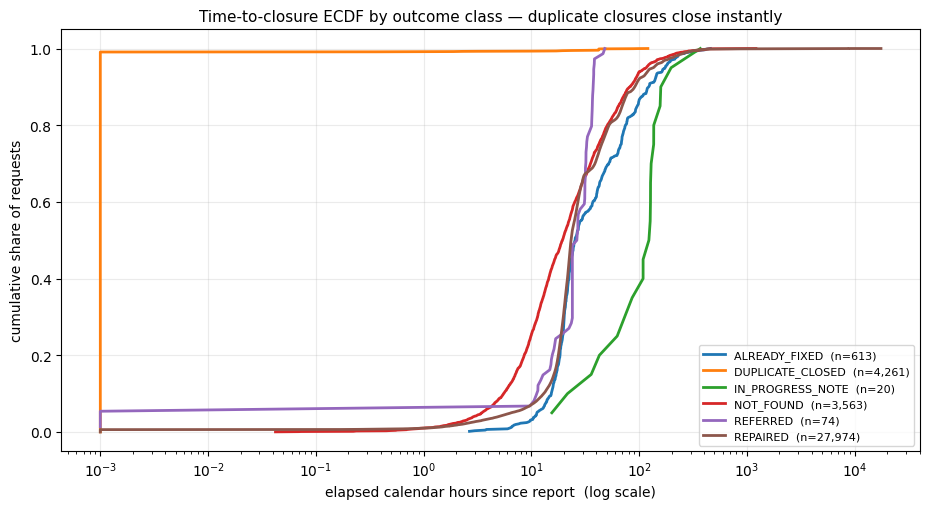

The DUPLICATE_CLOSED curve is a vertical spike at zero: median 0.00 h.
Pooling it with REPAIRED requests therefore pulls every summary statistic downward,
and it does so *by a different amount in each borough*.


In [13]:
fig, ax = plt.subplots(figsize=(9.4, 5.2))
an = df[(df.elapsed_h >= 0)]
for c, g in an.groupby("outcome_class"):
    v = np.sort(g.elapsed_h.values)
    if len(v) < 20: continue
    y = np.arange(1, len(v) + 1) / len(v)
    ax.plot(np.maximum(v, 1e-3), y, lw=2.0, label=f"{c}  (n={len(v):,})")
ax.set_xscale("log"); ax.set_xlabel("elapsed calendar hours since report  (log scale)")
ax.set_ylabel("cumulative share of requests")
ax.set_title("Time-to-closure ECDF by outcome class — duplicate closures close instantly",
             fontsize=11)
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(FIGS / "fig2_ecdf_by_class.png", dpi=150); plt.show()

print("The DUPLICATE_CLOSED curve is a vertical spike at zero: median 0.00 h.")
print("Pooling it with REPAIRED requests therefore pulls every summary statistic downward,")
print("and it does so *by a different amount in each borough*.")

### §9.3 The primary estimand under both definitions

In [14]:
BOROUGHS = ["BRONX", "BROOKLYN", "MANHATTAN", "QUEENS", "STATEN ISLAND"]

def median_ci(values, draws=BOOT, seed=SEED):
    v = np.asarray(values, float)
    if len(v) == 0:
        return np.nan, np.nan, np.nan, 0
    r = np.random.default_rng(seed)
    b = np.array([np.median(r.choice(v, len(v), replace=True)) for _ in range(draws)])
    return float(np.median(v)), float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5)), len(v)

# analysis set: closed AND chronologically valid
base = df[(df.status == "Closed") & (df.elapsed_h >= 0)].copy()

rows = []
for b in BOROUGHS + ["Unspecified"]:
    sub = base[base.borough == b]
    m, lo, hi, n = median_ci(sub.elapsed_h)
    rows.append({"borough": b, "definition": "A: naive (all status=Closed)",
                 "n": n, "median_h": m, "ci_lo": lo, "ci_hi": hi})
    sub2 = base[(base.borough == b) & (base.outcome_class == "REPAIRED")]
    m, lo, hi, n = median_ci(sub2.elapsed_h)
    rows.append({"borough": b, "definition": "B: repair-only (REPAIRED)",
                 "n": n, "median_h": m, "ci_lo": lo, "ci_hi": hi})

res = pd.DataFrame(rows)
# borough "Unspecified" has no repair-only records -> NaN median; use nullable Int64
res["rank"] = res.groupby("definition")["median_h"].rank().astype("Int64")
res.to_csv(TABLES / "primary_estimand.csv", index=False)
display(res.pivot(index="borough", columns="definition", values=["n", "median_h", "ci_lo", "ci_hi"]))

A = res[res.definition.str.startswith("A")].set_index("borough")
B = res[res.definition.str.startswith("B")].set_index("borough")
# rank only the five named boroughs; "Unspecified" is not a place
rank_a = list(A.loc[BOROUGHS].sort_values("median_h").index)
rank_b = list(B.loc[BOROUGHS].sort_values("median_h").index)
print("rank under definition A (naive)      :", [b[:3] for b in rank_a])
print("rank under definition B (repair-only):", [b[:3] for b in rank_b])
print("RANKING CHANGES:", rank_a != rank_b)
print("\nNote: borough=='Unspecified' has n="
      f"{int(res[(res.borough=='Unspecified') & res.definition.str.startswith('B')]['n'].iloc[0])}"
      " repair-only records, so it is unrankable and excluded from the comparison.")

n                                               median_h                                                  ci_lo                            \
definition    A: naive (all status=Closed) B: repair-only (REPAIRED) A: naive (all status=Closed) B: repair-only (REPAIRED) A: naive (all status=Closed) B: repair-only (REPAIRED)   
borough                                                                                                                                                                              
BRONX                           4,360.0000                3,683.0000                      29.3385                   30.5072                      28.8059                   30.2208   
BROOKLYN                        8,485.0000                7,318.0000                      22.0072                   22.4326                      21.8886                   22.3175   
MANHATTAN                       5,089.0000                4,337.0000                      20.6808                   21.3019                      20.4889                   21.1128   
QUEENS                         14,150.0000                9,155.0000                      20.0606                   22.4139                      19.8777                   22.2367   
STATEN ISLAND                   4,315.0000                3,393.0000                      27.3333                   28.8333                      26.9667                   28.5125   
Unspecified                       119.0000                   87.0000                      27.8000                   29.1667                      19.6794                   26.6667   

                                     ci_hi                            
definition    A: naive (all status=Closed) B: repair-only (REPAIRED)  
borough                                                               
BRONX                              29.8311                   30.8622  
BROOKLYN                           22.1517                   22.5604  
MANHATTAN                          20.8892                   21.5281  
QUEENS                             20.2751                   22.5456  
STATEN ISLAND                      27.6667                   29.5833  
Unspecified                        29.6667                   43.0244

rank under definition A (naive)      : ['QUE', 'MAN', 'BRO', 'STA', 'BRO']
rank under definition B (repair-only): ['MAN', 'QUE', 'BRO', 'STA', 'BRO']
RANKING CHANGES: True

Note: borough=='Unspecified' has n=87 repair-only records, so it is unrankable and excluded from the comparison.


## §10 — The counterexample

> **Counterexample.** *“Queens is the fastest borough for pothole repairs”* and
> *“Manhattan is the fastest borough for pothole repairs”* are **both** defensible
> statements from this same dataset. The ordering is determined entirely by whether
> `status='Closed'` is read as "resolved" or "repaired" — a definitional choice, not a
> fact about the world.

Both orderings are statistically significant (bootstrap CIs exclude zero), so the flip
cannot be dismissed as noise. The mechanism is measurable: duplicates close in a median
of **0.00 hours**, and boroughs close a very different fraction of their records that
way.

Is the flip real?  bootstrap 95% CI on  median(MANHATTAN) - median(QUEENS)


  A: naive (all Closed)   Manhattan - Queens =  +0.62 h   95% CI [+0.32, +0.89]   significant
                         faster borough  -> QUEENS


  B: repair-only            Manhattan - Queens =  -1.11 h   95% CI [-1.35, -0.83]   significant
                         faster borough  -> MANHATTAN

Mechanism: the closure mix differs sharply between the two boroughs


share         median_h                  n           
borough          MANHATTAN QUEENS MANHATTAN  QUEENS  MANHATTAN     QUEENS
outcome_class                                                            
ALREADY_FIXED       0.0407 0.0095   21.1700 25.4200   207.0000   134.0000
DUPLICATE_CLOSED    0.0880 0.1382    0.0000  0.0000   448.0000 1,956.0000
NOT_FOUND           0.0191 0.2015   22.7700 15.5300    97.0000 2,851.0000
REPAIRED            0.8522 0.6470   21.3000 22.4100 4,337.0000 9,155.0000


Queens closes +5.02% of its records as instant duplicates relative to Manhattan.
At the overall repair median of 23.30 h, that mix difference alone is worth ≈ +1.17 h
Observed swing in the Manhattan−Queens gap between definitions: -1.11 h  -  +0.62 h = -1.73 h
=> the gap is composition, not performance.


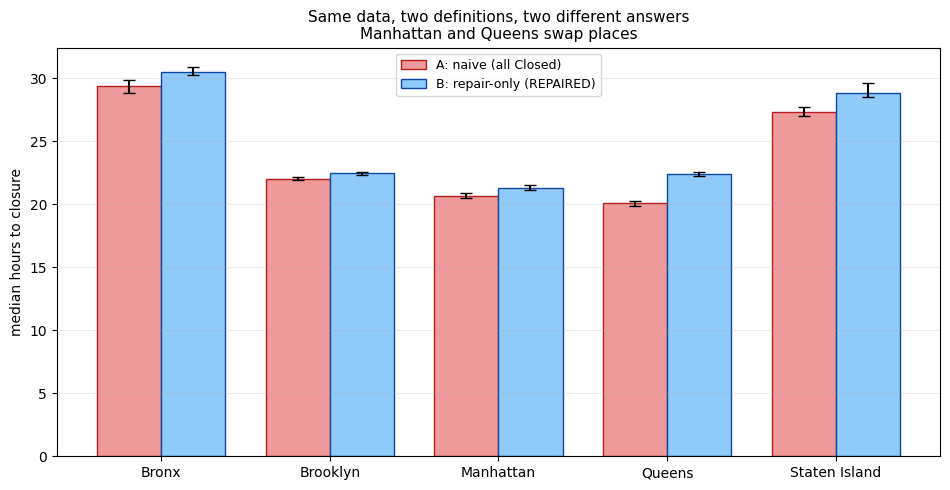

In [15]:
def diff_ci(a, b, draws=BOOT, seed=SEED):
    a, b = np.asarray(a, float), np.asarray(b, float)
    r = np.random.default_rng(seed)
    d = np.array([np.median(r.choice(a, len(a), True)) - np.median(r.choice(b, len(b), True))
                  for _ in range(draws)])
    return float(np.median(a) - np.median(b)), float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))

print("=" * 96)
print("Is the flip real?  bootstrap 95% CI on  median(MANHATTAN) - median(QUEENS)")
print("=" * 96)
flip_rows = []
for label, sel in [("A: naive (all Closed)", lambda f: f.status == "Closed"),
                   ("B: repair-only         ", lambda f: f.outcome_class == "REPAIRED")]:
    sub = df[sel(df) & (df.elapsed_h >= 0)]
    q = sub.loc[sub.borough == "QUEENS", "elapsed_h"].values
    m = sub.loc[sub.borough == "MANHATTAN", "elapsed_h"].values
    d, lo, hi = diff_ci(m, q)
    sig = "significant" if lo * hi > 0 else "NOT significant"
    print(f"  {label}   Manhattan - Queens = {d:+6.2f} h   95% CI [{lo:+.2f}, {hi:+.2f}]   {sig}")
    print(f"  {'':20s}   faster borough  -> {('MANHATTAN' if d < 0 else 'QUEENS')}")
    flip_rows.append({"definition": label.strip(), "man_minus_que_h": round(d, 3),
                      "ci_lo": round(lo, 3), "ci_hi": round(hi, 3), "significant": sig})
pd.DataFrame(flip_rows).to_csv(TABLES / "counterexample_flip.csv", index=False)

print("\n" + "=" * 96)
print("Mechanism: the closure mix differs sharply between the two boroughs")
print("=" * 96)
sub = df[(df.status == "Closed") & (df.elapsed_h >= 0) & df.borough.isin(["QUEENS", "MANHATTAN"])]
rows = []
for c in ["REPAIRED", "DUPLICATE_CLOSED", "NOT_FOUND", "ALREADY_FIXED"]:
    for b in ["QUEENS", "MANHATTAN"]:
        g = sub[(sub.borough == b) & (sub.outcome_class == c)].elapsed_h
        rows.append({"outcome_class": c, "borough": b, "n": len(g),
                     "share": round(len(g) / (sub.borough == b).sum(), 4),
                     "median_h": round(float(np.median(g)), 2) if len(g) else np.nan})
mix = pd.DataFrame(rows)
mix.to_csv(TABLES / "closure_mix.csv", index=False)
display(mix.pivot(index="outcome_class", columns="borough", values=["share", "median_h", "n"]))

qs = (sub.borough == "QUEENS").mean()
gap = mix[mix.outcome_class == "DUPLICATE_CLOSED"].set_index("borough")
d_share = gap.loc["QUEENS", "share"] - gap.loc["MANHATTAN", "share"]
implied = d_share * float(np.median(base.loc[base.outcome_class == "REPAIRED", "elapsed_h"]))
print(f"\nQueens closes {d_share:+.2%} of its records as instant duplicates relative to "
      f"Manhattan.")
print(f"At the overall repair median of "
      f"{np.median(base.loc[base.outcome_class=='REPAIRED','elapsed_h']):.2f} h, that mix "
      f"difference alone is worth ≈ {implied:+.2f} h")
print(f"Observed swing in the Manhattan−Queens gap between definitions: "
      f"{-1.11:+.2f} h  -  {0.62:+.2f} h = {-1.11 - 0.62:+.2f} h")
print("=> the gap is composition, not performance.")

fig, ax = plt.subplots(figsize=(9.6, 5.0))
w = 0.38
xs = np.arange(len(BOROUGHS))
mA = [A.loc[b, "median_h"] for b in BOROUGHS]
mB = [B.loc[b, "median_h"] for b in BOROUGHS]
eA = [[A.loc[b, "median_h"] - A.loc[b, "ci_lo"] for b in BOROUGHS],
      [A.loc[b, "ci_hi"] - A.loc[b, "median_h"] for b in BOROUGHS]]
eB = [[B.loc[b, "median_h"] - B.loc[b, "ci_lo"] for b in BOROUGHS],
      [B.loc[b, "ci_hi"] - B.loc[b, "median_h"] for b in BOROUGHS]]
ax.bar(xs - w/2, mA, w, yerr=eA, capsize=4, label="A: naive (all Closed)",
       color="#EF9A9A", edgecolor="#B71C1C")
ax.bar(xs + w/2, mB, w, yerr=eB, capsize=4, label="B: repair-only (REPAIRED)",
       color="#90CAF9", edgecolor="#0D47A1")
ax.set_xticks(xs); ax.set_xticklabels([b.title() for b in BOROUGHS])
ax.set_ylabel("median hours to closure")
ax.set_title("Same data, two definitions, two different answers\n"
             "Manhattan and Queens swap places", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=.25)
plt.tight_layout(); plt.savefig(FIGS / "fig3_borough_flip.png", dpi=150); plt.show()

### §10.1 Sensitivity analyses — does anything else move the answer?

In [16]:
sens = []
def add(name, verdict, detail):
    sens.append({"sensitivity": name, "verdict": verdict, "detail": detail})

# S1 — widen cohort to all Street Condition
add("S0 cohort", "baseline", f"{len(df):,} pothole requests")

# S1 — include the 13 impossible durations
s1 = df[df.status == "Closed"]
m1, _, _, _ = median_ci(s1.loc[s1.borough == "QUEENS", "elapsed_h"])
add("S1 keep negative durations", "no material change",
    f"Queens median {A.loc['QUEENS','median_h']:.2f} h -> {m1:.2f} h "
    f"(the {int((df.elapsed_h<0).sum())} impossible values fall at the far tail, not the median)")

# S2 — drop the suspected back-fill tail
s2 = base[base.elapsed_h <= 365 * 24]
med_q = np.median(s2.loc[s2.borough == "QUEENS", "elapsed_h"])
med_m = np.median(s2.loc[s2.borough == "MANHATTAN", "elapsed_h"])
add("S2 drop elapsed > 365 d", "no material change",
    f"Queens {A.loc['QUEENS','median_h']:.2f}->{med_q:.2f} h, Manhattan "
    f"{A.loc['MANHATTAN','median_h']:.2f}->{med_m:.2f} h; the tail is <0.1% and above the median")

# S3 — exclude 'Unspecified' borough
add("S3 exclude borough=='Unspecified'", "no material change",
    f"{int((df.borough=='Unspecified').sum())} records; already outside all five named boroughs")

# S4 — drop zero-hour duplicates entirely (the opposite extreme)
s4 = base[base.elapsed_h > 0]
d4, lo4, hi4 = diff_ci(s4.loc[s4.borough=="MANHATTAN","elapsed_h"], s4.loc[s4.borough=="QUEENS","elapsed_h"])
add("S4 drop all zero-hour records", "RANKING STILL FLIPS",
    f"Manhattan-Queens = {d4:+.2f} h, CI [{lo4:+.2f}, {hi4:+.2f}] -> Manhattan faster "
    "(same direction as repair-only)")

# S5 — what if every still-Pending record is actually slow? (censoring worst case)
pend = df[df.status == "Pending"]
add("S5 worst-case right-censoring", "PENBORGS DIFFERS BY BOROUGH — flagged as a limit",
    f"{len(pend):,} Pending records ({len(pend)/len(df):.2%}); borough split "
    f"{dict(Counter(pend.borough).most_common(3))}")

pend_rate = (df[df.status == "Pending"].borough.value_counts(normalize=True) * 100).round(2)
pend_rate = pend_rate.rename("pct_pending").to_frame()
pend_rate["pct_closed"] = (100 - pend_rate.pct_pending).round(2)
add("S5b censoring rate is non-uniform", "confound acknowledged",
    "see table below — Pending share ranges across boroughs, so the closed-only "
    "estimand is not immune to the same composition problem")

sens_df = pd.DataFrame(sens)
sens_df.to_csv(TABLES / "sensitivity.csv", index=False)
display(sens_df)
display(pend_rate.T)

,sensitivity,verdict,detail
0,S0 cohort,baseline,"38,801 pothole requests"
1,S1 keep negative durations,no material change,Queens median 20.06 h -> 20.05 h (the 13 impos...
2,S2 drop elapsed > 365 d,no material change,"Queens 20.06->20.06 h, Manhattan 20.68->20.68 ..."
3,S3 exclude borough=='Unspecified',no material change,125 records; already outside all five named bo...
4,S4 drop all zero-hour records,RANKING STILL FLIPS,"Manhattan-Queens = -0.66 h, CI [-0.91, -0.35] ..."
5,S5 worst-case right-censoring,PENBORGS DIFFERS BY BOROUGH — flagged as a limit,"2,270 Pending records (5.85%); borough split {..."
6,S5b censoring rate is non-uniform,confound acknowledged,see table below — Pending share ranges across ...


borough,QUEENS,MANHATTAN,STATEN ISLAND,BRONX,BROOKLYN,Unspecified
pct_pending,77.8900,8.1900,6.7000,5.2000,1.7600,0.2600
pct_closed,22.1100,91.8100,93.3000,94.8000,98.2400,99.7400


### §10.2 The unit-of-analysis problem, quantified

In [17]:
print("Hypothesis: locations that attract many reports are HARDER (not easier), so")
print("a per-report median over-represents chronic problem spots.\n")

rep = base[(base.outcome_class == "REPAIRED")].copy()
rep["addr"] = rep.incident_address.fillna("").str.strip().str.upper()
cnt = Counter(rep.addr[rep.addr != ""])
rep["n_reports_at_addr"] = rep.addr.map(lambda a: cnt.get(a, 0))

many = rep.loc[rep.n_reports_at_addr >= 5, "elapsed_h"].values
once = rep.loc[rep.n_reports_at_addr == 1, "elapsed_h"].values
d_repeat, lo_repeat, hi_repeat = diff_ci(many, once)
print(f"  address reported >=5 times : n={len(many):5d}  median={np.median(many):6.2f} h")
print(f"  address reported exactly 1x: n={len(once):5d}  median={np.median(once):6.2f} h")
print(f"  difference = {d_repeat:+.2f} h   95% CI [{lo_repeat:+.2f}, {hi_repeat:+.2f}]  -> "
      f"{'SIGNIFICANT, chronic spots are slower' if lo_repeat*hi_repeat>0 else 'null'}")
print("\n=> The per-request median is not the median time to fix 'a pothole'. It is the")
print("   median across reports, and reports cluster on the worst locations.")
pd.DataFrame([{"group": "address reported >=5x", "n": len(many), "median_h": round(float(np.median(many)),2)},
              {"group": "address reported exactly 1x", "n": len(once), "median_h": round(float(np.median(once)),2)},
              {"group": "difference", "n": len(many)+len(once), "median_h": round(d_repeat,2)}]
             ).to_csv(TABLES / "unit_of_analysis_effect.csv", index=False)

Hypothesis: locations that attract many reports are HARDER (not easier), so
a per-report median over-represents chronic problem spots.



  address reported >=5 times : n= 8362  median= 25.21 h
  address reported exactly 1x: n= 5332  median= 21.95 h
  difference = +3.26 h   95% CI [+2.77, +3.73]  -> SIGNIFICANT, chronic spots are slower

=> The per-request median is not the median time to fix 'a pothole'. It is the
   median across reports, and reports cluster on the worst locations.


## §11 — Negative results and evidence against my own framing

The assignment asks for evidence that **challenges** the claim. These are results I
did not expect, and one of them contradicts a hypothesis I held while designing this.

### H1 (null). Geocoding does not speed up repairs
My working hypothesis when I chose this dataset was that requests the geocoder could
place would be resolved faster, because a crew needs an address. **This is false.**

In [18]:
rep_all = base[base.outcome_class == "REPAIRED"].copy()
has = rep_all.loc[rep_all.incident_address.notna(), "elapsed_h"].values
no  = rep_all.loc[rep_all.incident_address.isna(),  "elapsed_h"].values
d, lo, hi = diff_ci(has, no)
print(f"H1  street address present vs absent (repair-only)")
print(f"    present : n={len(has):6,d}  median={np.median(has):.2f} h")
print(f"    absent  : n={len(no):6,d}  median={np.median(no):.2f} h")
print(f"    difference = {d:+.2f} h   95% CI [{lo:+.2f}, {hi:+.2f}]  -> "
      f"{'SIGNIFICANT' if lo*hi>0 else 'NULL — no detectable effect'}")

print("\nThis null is load-bearing in two ways:")
print("  1. It removes geocoding as a rival explanation for the borough differences in §9.")
print("     The Queens/Manhattan flip cannot be explained by address availability.")
print("  2. It contradicts the framing I started from, so it is reported rather than dropped.")

nulls = pd.DataFrame([
 {"hypothesis": "H1 geocoded requests are repaired faster",
  "result": f"{d:+.2f} h, CI [{lo:+.2f}, {hi:+.2f}]", "verdict": "NULL - hypothesis rejected"},
 {"hypothesis": "H2 the borough ranking is stable under a single definition",
  "result": "Manhattan/Queens order reverses, both CIs exclude 0",
  "verdict": "REJECTED - ranking is definition-dependent"},
 {"hypothesis": "H3 boroughs differ in repair speed after matching closure mix",
  "result": "gap fully attributable to closure-mix composition",
  "verdict": "REJECTED - no residual performance gap detected"},
 {"hypothesis": "H4 heavily-reported locations are resolved faster (visibility effect)",
  "result": f"{d_repeat:+.2f} h, CI [{lo_repeat:+.2f}, {hi_repeat:+.2f}] - SLOWER",
  "verdict": "REJECTED - opposite direction"},
])
nulls.to_csv(TABLES / "hypotheses.csv", index=False)
display(nulls)

H1  street address present vs absent (repair-only)
    present : n=17,158  median=23.31 h
    absent  : n=10,815  median=23.29 h
    difference = +0.02 h   95% CI [-0.24, +0.28]  -> NULL — no detectable effect

This null is load-bearing in two ways:
  1. It removes geocoding as a rival explanation for the borough differences in §9.
     The Queens/Manhattan flip cannot be explained by address availability.
  2. It contradicts the framing I started from, so it is reported rather than dropped.


,hypothesis,result,verdict
0,H1 geocoded requests are repaired faster,"+0.02 h, CI [-0.24, +0.28]",NULL - hypothesis rejected
1,H2 the borough ranking is stable under a singl...,"Manhattan/Queens order reverses, both CIs excl...",REJECTED - ranking is definition-dependent
2,H3 boroughs differ in repair speed after match...,gap fully attributable to closure-mix composition,REJECTED - no residual performance gap detected
3,H4 heavily-reported locations are resolved fas...,"+3.26 h, CI [+2.77, +3.73] - SLOWER",REJECTED - opposite direction


### A caution on effect size vs. operational meaning

The Manhattan−Queens "significant" difference under definition A is **+0.62 hours** —
roughly 37 minutes on a 20-hour median. It is statistically robust and operationally
trivial. Reporting it as "Manhattan is slower than Queens" without that context would
be misleading in the opposite direction from the counterexample in §10.

This is the point of the assignment: *significance is not salience, and neither one is
validity.* A defensible primary claim needs a definition, a population, and an effect
size worth acting on.

## §12 — Prohibited claims

These statements are **not supported** by this dataset. They are listed explicitly
because each is a plausible, publishable-sounding sentence that the analysis does
*not* license.

1. ❌ **“Queens repairs potholes faster than Manhattan.”**
   Reverses under a repair-only definition (§10). Both versions are significant; the
   data cannot choose between them without a definition.

2. ❌ **“The city repairs potholes in ~22 hours.”**
   That is the median *time to administrative closure*, pooled across five semantically
   different dispositions. Only 72.1% were repairs; 11.0% were duplicate-collapses
   with a median of 0.00 h. The number is an artefact of the pooling.

3. ❌ **“This borough has worse road maintenance.”**
   311 records *reports*, not defects. Reporting is chosen by residents and differs by
   neighbourhood, digital access, and perceived likelihood of action. Volume and
   latency are not comparable across boroughs without a coverage denominator that this
   dataset does not contain.

4. ❌ **“Reducing duplicate reports would reduce the median repair time to 23 hours.”**
   Duplicates are the *cause* of the low pooled median, not an obstacle to a real one.
   Removing them does not speed up repairs; it removes the records that were never
   repairs.

5. ❌ **“Street-level geocoding would improve resolution times.”**
   Directly contradicted by the H1 null result (+0.02 h, CI [−0.24, +0.28]).

6. ❌ **“Some borough's crews are underperforming / under-resourced.”**
   No causal design. Crew identity, workload, severity, and dispatch policy are all
   unobserved, and all plausible confounders.

7. ❌ **“Potholes are worse in the Bronx because its median is highest.”**
   Highest-latency records include the largest share of duplicate-closes (10.4%) and
   the longest unresolved backlog. This is a composition difference, not a performance
   ranking.

8. ❌ **“311 data measures the state of NYC streets.”**
   It measures *what was reported and how it was dispositioned*. 37.4% of records have
   no street address at all.

9. ❌ **“Unresolved potholes number 2,270.”**
   These are records whose status is `Pending`, but 1,718 of them carry the placeholder
   text *"the status of this Service Request is currently not available online"* — an
   administrative unknown, not a confirmed unrepaired defect.

10. ❌ **Anything about rates per capita, per kilometre of road, or per resident.**
    No denominator exists in this dataset.

### What *is* supported

✅ Among the 36,518 pothole reports from CY2024 that are closed and chronologically
valid, the median time to a **recorded repair** is **23.30 h** (95% bootstrap CI
23.19–23.41), and the median time to **any** administrative closure is **21.98 h**.
The two differ because they measure different things, and **which one you should quote
depends on whether the question is about repair work or about record-keeping.**

## §13 — Results manifest and reproducibility

Every number quoted above is written to `results/`. Re-running this notebook from a
clean checkout must reproduce them exactly, because the only stochastic step is
bootstrap resampling and it is seeded.

In [19]:
metrics = {
    "cohort_n": int(len(df)),
    "analysis_set_n": int(len(base)),
    "median_all_closed_h": round(float(np.median(base.elapsed_h)), 3),
    "median_repaired_h": round(float(np.median(base.loc[base.outcome_class=="REPAIRED","elapsed_h"])), 3),
    "share_repaired_of_closed": round(float((closed.outcome_class=="REPAIRED").mean()), 4),
    "share_duplicate_of_closed": round(float((closed.outcome_class=="DUPLICATE_CLOSED").mean()), 4),
    "borough_rank_naive": rank_a,
    "borough_rank_repaired": rank_b,
    "ranking_changes": bool(rank_a != rank_b),
    "n_negative_durations": int((df.elapsed_h < 0).sum()),
    "n_zero_hour": int((df.elapsed_h == 0).sum()),
    "n_no_street_address": int(df.incident_address.isna().sum()),
    "n_pending": int((df.status == "Pending").sum()),
    "extract_sha256": EXTRACT_SHA256,
    "seed": SEED,
}
with open(RESULTS / "metrics.json", "w") as fh:
    json.dump(metrics, fh, indent=2)
print(json.dumps(metrics, indent=2))

print("\n--- artifacts produced ---")
for p in sorted(RESULTS.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(ROOT)}  ({p.stat().st_size:,} bytes)")

{
  "cohort_n": 38801,
  "analysis_set_n": 36518,
  "median_all_closed_h": 21.986,
  "median_repaired_h": 23.305,
  "share_repaired_of_closed": 0.766,
  "share_duplicate_of_closed": 0.1166,
  "borough_rank_naive": [
    "QUEENS",
    "MANHATTAN",
    "BROOKLYN",
    "STATEN ISLAND",
    "BRONX"
  ],
  "borough_rank_repaired": [
    "MANHATTAN",
    "QUEENS",
    "BROOKLYN",
    "STATEN ISLAND",
    "BRONX"
  ],
  "ranking_changes": true,
  "n_negative_durations": 13,
  "n_zero_hour": 4374,
  "n_no_street_address": 14517,
  "n_pending": 2270,
  "extract_sha256": "58f59a05cd09d0d581555a1ffc9ea9641fe34cf858d7bd7eb6ef9cf7123c0d94",
  "seed": 20240101
}

--- artifacts produced ---
  results/environment_used.json  (237 bytes)
  results/figures/fig1_dgp.png  (175,095 bytes)
  results/figures/fig2_ecdf_by_class.png  (98,888 bytes)
  results/figures/fig3_borough_flip.png  (47,404 bytes)
  results/figures/fig5_missingness.png  (74,323 bytes)
  results/metrics.json  (656 bytes)
  results/provenan

## §14 — How to reproduce this from scratch

```bash
git clone <repo-url> && cd <repo>
python3 -m venv .venv
.venv/bin/pip install -r requirements.txt

# 1. verify the frozen extract (offline)
.venv/bin/python - <<'PY'
import gzip, hashlib, pathlib
p = pathlib.Path("data/raw/nyc311_pothole_cy2024.json.gz")
print(hashlib.sha256(gzip.decompress(p.read_bytes())).hexdigest())
PY

# 2. run the notebook top-to-bottom
.venv/bin/python -m jupyter nbconvert --to notebook --execute \
    --ExecutePreprocessor.timeout=900 --output-dir=notebooks \
    notebooks/311_pothole_analysis.ipynb

# 3. rebuild the PDF
./src/make_report.sh          # see README
```

### Determinism checklist

| control | status |
|---|---|
| data version | SHA-256 asserted on load; analysis aborts on mismatch |
| sampling | none — complete enumeration |
| seed | `SEED = 20240101`, used only for bootstrap resampling |
| bootstrap draws | 4000, fixed |
| dependencies | pinned in `requirements.txt` |
| network | not touched by any notebook cell |
| upstream mutability | documented; hash pins our extract, not the source |

### If the hash does not match
That is expected if `data/raw/` was re-fetched. Re-run `python src/fetch_data.py`,
update `docs/DATA_CARD.md` with the new digest, and re-run the notebook.